# Mitogenomes reveal timing in Beringian birds - bad mtDNA analysis

-----
| Name | Date | 
| - | - |
| Keiler Collier | 29 March 2026 |

## Background information
On 26 March 2026, George Sangster emailed Kevin Winker about reference-based contamination in the mitogenomes in my thesis Chapter 1.

Here, we will contain the code/analysis involved in finding where the errors in Brant Faircloth's pipeline (as followed by KCollier) came from.

### Why visualize depth?

Mitogenomic assembly success is greatly affected by data coverage and quality, particularly in repetitive regions.
These, in turn, are affected by tissue type and preservation method, and are therefore highly variable across samples.
I don't have the tissue types (although I could get them from the flat file), but we should look at depth distribution

## Goals

1. Load [raw data](#1-data-and-parameters)
2. Visualize the distribution of mitogenome coverages with a [violin plot](#2-violinplot-of-mtdna-coverage)
3. Provide [summary statistics](#3-summary-stats-of-mtdna-coverage) of mitogenome coverage
4. [Interpret](#4-interpretation-of-mtdna-coverage) mitogenome coverages

-----

## 1. Data and parameters

We define our parameters and read in raw data.

$30$ is used as a threshold for high-coverage mitogenomes because it's the genome assembly literature's 'rule-of-thumb' value, at which we consider heterozygous calls to be reliable.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Use canonical merged results and keep confident matches for coverage/order analysis.
threshold = 30
df = pd.read_csv('mitogenome_assembly_results.csv')

required_cols = {'coverage', 'order', 'match_status'}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise ValueError(f'Missing required columns: {sorted(missing_cols)}')

# Keep rows with reliable metadata and harmonize names for plotting.
df = df.loc[df['match_status'].eq('matched')].copy()
df['Coverage'] = pd.to_numeric(df['coverage'], errors='coerce')
df['Order'] = df['order']
df = df.dropna(subset=['Coverage', 'Order'])
df

,directory_name,species,assembly_level,catalog_guess,accession_guess,coverage,order,taxon_pair,species_old,match_status,match_confidence,match_notes,_merge,Coverage,Order
0,Anas_acuta_UAM_22113_REW601,Anas acuta,partial_success,UAM22113,REW601,9.8,Anseriformes,Anas acuta,Anas acuta,matched,high,NaN,both,9.8,Anseriformes
1,Anas_acuta_UAM_23468_KGM895,Anas acuta,partial_success,UAM23468,KGM895,48.3,Anseriformes,Anas acuta,Anas acuta,matched,high,NaN,both,48.3,Anseriformes
2,Anas_acuta_UAM_28156_KSW5107,Anas acuta,partial_success,UAM28156,KSW5107,31.3,Anseriformes,Anas acuta,Anas acuta,matched,high,NaN,both,31.3,Anseriformes
3,Anas_acuta_UAM_28167_KSW5120,Anas acuta,partial_success,UAM28167,KSW5120,23.2,Anseriformes,Anas acuta,Anas acuta,matched,high,NaN,both,23.2,Anseriformes
4,Anas_acuta_UAM_29039_REW548,Anas acuta,partial_success,UAM29039,REW548,22.8,Anseriformes,Anas acuta,Anas acuta,matched,high,NaN,both,22.8,Anseriformes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Uria_lomvia_arra_UWBM_44177_JMB1001,Uria lomvia arra,partial_success,UWBM44177,JMB1001,16.9,Charadriiformes,Uria l,Uria lomvia arra,matched,high,NaN,both,16.9,Charadriiformes
284,Uria_lomvia_arra_UWBM_44178_JMB1002,Uria lomvia arra,failed,UWBM44178,JMB1002,17.8,Charadriiformes,Uria l,Uria lomvia arra,matched,high,NaN,both,17.8,Charadriiformes
285,Uria_lomvia_arra_UWBM_55300_BKS351,Uria lomvia arra,failed,UWBM55300,BKS351,11.0,Charadriiformes,Uria l,Uria lomvia arra,matched,high,NaN,both,11.0,Charadriiformes
286,Uria_lomvia_arra_UWBM_55725_JMB857,Uria lomvia arra,failed,UWBM55725,JMB857,11.4,Charadriiformes,Uria l,Uria lomvia arra,matched,high,NaN,both,11.4,Charadriiformes


-----

## 2. Violinplot of mtDNA coverage

This is a [violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html) of coverage, with a threshold line at $30$ x coverage.

The raw data is derived from "Table S3. Mitogenome coverage depths per individual specimen. Institution abbreviations are UAM for the University of Alaska Museum and UWBM for the University of Washington Burke Museum."

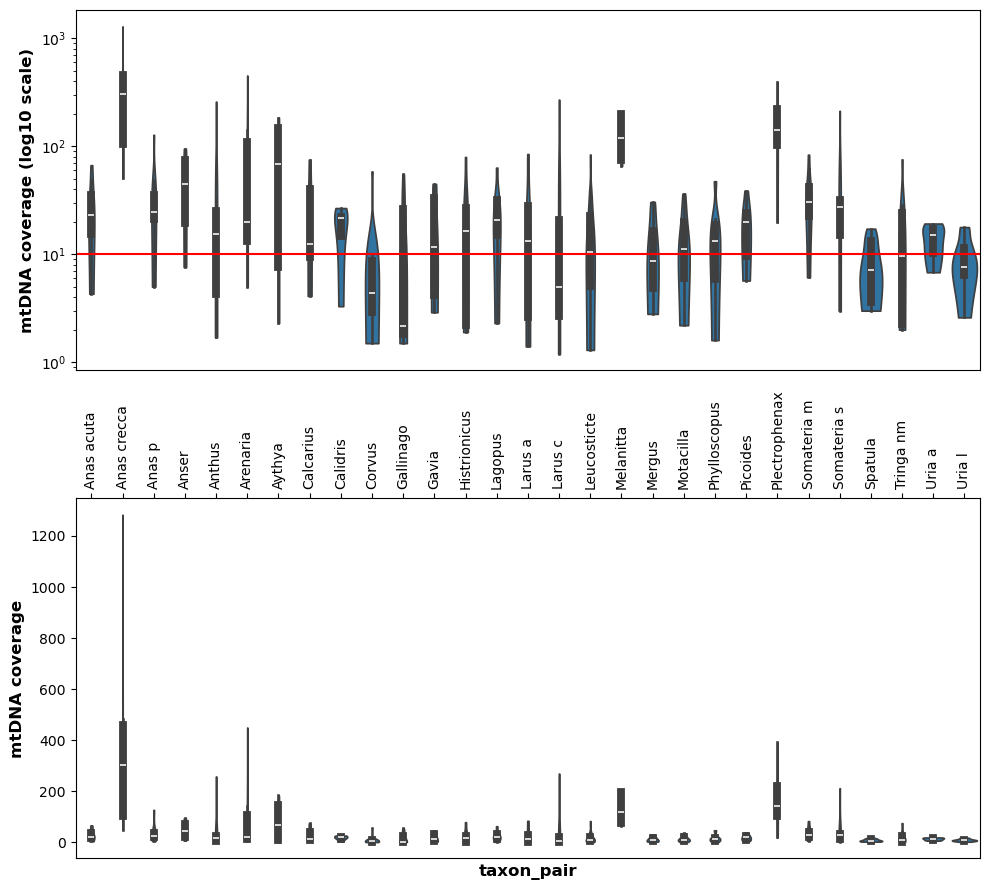

In [16]:
fig, (ax_log, ax_lin) = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
sns.violinplot(data=df, x="taxon_pair", y="Coverage", ax=ax_log, inner="box", cut=0)
ax_log.set_yscale("log")
ax_log.set_ylabel("mtDNA coverage (log10 scale)", fontsize=12, fontweight="bold")

ax_log.set_xlabel("")
ax_log.axhline(y=10, color='r', linestyle='-')
ax_log.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)

sns.violinplot(data=df, x="taxon_pair", y="Coverage", ax=ax_lin, inner="box", cut=0)
ax_lin.set_ylabel("mtDNA coverage", fontsize=12, fontweight="bold")
# Category names on the top spine of the lower panel (between log and linear axes).
ax_lin.xaxis.tick_top()
ax_lin.tick_params(
    axis="x",
    rotation=90,
    bottom=False,
    labelbottom=False,
    top=True,
    labeltop=True,
)
ax_lin.set_xlabel("taxon_pair", fontsize=12, fontweight="bold")
ax_lin.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.show()

## 3. Summary stats of mtdna coverage

In [17]:
sumstats = df.groupby("taxon_pair")["Coverage"].describe()
print(sumstats)

               count        mean         std   min      25%     50%      75%  \
taxon_pair                                                                     
Anas acuta       8.0   27.962500   20.592297   4.3   15.500   23.00   35.550   
Anas crecca      9.0  361.811111  380.242421  50.2  104.300  304.60  459.400   
Anas p          10.0   35.770000   34.172082   5.0   21.000   24.65   35.425   
Anser            8.0   47.475000   33.617247   7.6   19.525   44.75   73.850   
Anthus           9.0   41.133333   82.100228   1.7    4.300   15.40   25.300   
Arenaria         7.0  102.671429  160.784646   5.0   13.100   20.00  108.850   
Aythya          10.0   78.360000   75.672014   2.3    7.575   68.35  145.750   
Calcarius        5.0   28.120000   29.571219   4.1    9.400   12.30   40.000   
Calidris         5.0   17.740000    9.124308   3.3   14.800   21.70   22.200   
Corvus          15.0    8.646667   13.993716   1.5    2.900    4.40    8.550   
Gallinago       10.0   14.170000   19.15

In [13]:
df.describe()

,coverage,Coverage
count,274.000000,274.000000
mean,42.801825,42.801825
std,103.319209,103.319209
min,1.200000,1.200000
25%,5.500000,5.500000
50%,15.150000,15.150000
75%,32.525000,32.525000
max,1282.900000,1282.900000


## 4. Interpretation of mtDNA coverage

Our mitogenome coverage values are spread over 4 orders of magnitude, with an overall average of $419.00\pm 231.8$ x.
However, this universal mean is misleading: it is driven by a small number of high-coverage lineages and individuals - most notably the *Clangula* taxon-pair, which averages $496.83 \pm 872.69$.
(I did not explicitly test for differences among lineages, but visually, taxon-pair clearly affects the average mitogenomic coverage.)

More problematically, $\frac{221}{424}$ ($52\%$) mitogenomes and $\frac{17}{39}$ ($43\%$ ) taxon-pairs used in this paper were under 30x coverage.
These would be **considered low-coverage** in modern de-novo assembly efforts.

As such, large portions of the dataset could be reasonably expected to be susceptible to reference contamination.

In [18]:
taxa_below_x=sumstats[sumstats["mean"] <= threshold]
num_under_xcov=len(df[df["Coverage"] <= threshold])
percent_under_xcov=num_under_xcov/len(df)*100

print(f"{num_under_xcov} ({percent_under_xcov:.2f}%) of our individual mitogenomes are below {threshold}x coverage.")

n_orders = len(sumstats)
print(f"{len(taxa_below_x)} ({len(taxa_below_x)/n_orders*100:.2f}%) orders have average values below {threshold}x coverage:")
for taxon, row in taxa_below_x.iterrows():
    std_disp = f"{row['std']:.2f}" if pd.notna(row["std"]) else "n/a"
    print(f"  {taxon}: {row['mean']:.2f} ± {std_disp}")


196 (71.53%) of our individual mitogenomes are below 30x coverage.
18 (62.07%) orders have average values below 30x coverage:
  Anas acuta: 27.96 ± 20.59
  Calcarius: 28.12 ± 29.57
  Calidris: 17.74 ± 9.12
  Corvus: 8.65 ± 13.99
  Gallinago: 14.17 ± 19.15
  Gavia: 18.74 ± 17.35
  Histrionicus: 22.60 ± 26.48
  Lagopus: 23.48 ± 17.81
  Larus a: 25.11 ± 30.40
  Leucosticte: 16.92 ± 19.13
  Mergus: 12.80 ± 10.03
  Motacilla: 14.06 ± 10.85
  Phylloscopus: 16.00 ± 14.03
  Picoides: 18.74 ± 11.60
  Spatula: 8.38 ± 5.05
  Tringa nm: 17.45 ± 22.71
  Uria a: 13.67 ± 4.70
  Uria l: 9.40 ± 4.89
